In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
url = "https://drive.google.com/file/d/1vjndDYb52a3nfAhZmXK_7KtaHf-JUIkf/view?usp=share_link"
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url)
df.timestamp = pd.to_datetime(df.timestamp).dt.date
df.timestamp = pd.to_datetime(df.timestamp)

df = df.pivot_table(index='timestamp', columns='symbol', values='close').ffill()
df.index = pd.to_datetime(df.index)

## convert to monthly stock price
df_weekly = df.resample('W').last().ffill()
price_daily = df.copy()
returns_daily = price_daily.pct_change().dropna()

price_weekly = df_weekly.copy()
returns_weekly = price_weekly.pct_change().dropna()

In [ ]:
df

symbol,ACB,ASM,BVH,CII,CTD,CTG,DBC,DIG,DLG,DPM,...,TCM,TSC,TTF,VCB,VCG,VHC,VIC,VIX,VND,VNM
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-02-06,2.83,2.33,42.86,13.76,29.41,9.23,4.24,4.92,4.46,15.34,...,10.71,2.36,8.31,6.89,5.72,4.69,21.20,1.12,1.45,35.75
2014-02-07,2.83,2.43,41.42,14.10,29.41,9.18,4.23,5.13,4.62,15.48,...,10.71,2.41,7.81,6.87,5.57,4.69,20.91,1.03,1.42,35.75
2014-02-10,2.83,2.47,41.42,14.87,29.41,9.12,4.44,5.34,4.62,15.61,...,10.86,2.52,7.91,6.99,5.67,4.69,21.34,1.09,1.46,35.75
2014-02-11,2.85,2.40,41.07,14.87,28.14,9.12,4.33,5.06,4.38,15.48,...,10.82,2.44,7.91,6.99,5.87,4.88,21.48,1.09,1.45,35.50
2014-02-12,2.87,2.50,43.13,15.63,28.78,9.18,4.40,5.09,4.54,15.61,...,10.90,2.52,8.21,7.17,6.43,4.63,21.76,1.09,1.47,35.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-14,26.00,8.04,53.60,14.10,83.00,42.30,29.35,20.65,1.97,35.65,...,41.10,2.55,3.11,66.00,20.90,67.00,52.20,12.30,14.95,62.10
2025-03-17,26.20,8.10,53.00,14.35,84.00,42.60,29.40,21.05,1.97,35.70,...,41.05,2.59,3.11,67.30,20.90,67.40,52.10,12.30,14.90,63.00
2025-03-18,26.30,8.14,53.30,14.45,83.20,42.00,29.40,20.85,1.99,35.70,...,40.70,2.65,3.13,66.80,20.50,68.10,51.30,12.20,15.20,62.50


## Ex ante volatilty

In [ ]:
def exante_volatility(returns, com=60, annualization=252):
    """
    Compute the ex ante annualized volatility using an exponentially weighted variance
    with the center of mass (com) parameter.

    The formula is:
      σ_t^2 = 261 * Σ_{i=0}^∞ w_i (r_{t-1-i} - r̄_t)^2,
    where the weights are given by the exponential decay with:
      alpha = 1 / (com + 1).

    Parameters:
        returns (pd.Series): Asset returns.
        com (int): Center of mass for the exponential weights (default is 60).

    Returns:
        pd.Series: The ex ante volatility σ_t (annualized by multiplying the variance by 261).
                   Volatility is computed using returns up to t-1.
    """
    # Shift returns by 1 so volatility at time t uses only past returns.
    ewm_variance = returns.ewm(com=com, adjust=False,min_periods=com).var()
    sigma = np.sqrt(annualization * ewm_variance)
    return sigma

exante_vol_daily = returns_daily.apply(exante_volatility)
vol = exante_vol_daily.resample('W').last().ffill()
vol

symbol,ACB,ASM,BVH,CII,CTD,CTG,DBC,DIG,DLG,DPM,...,TCM,TSC,TTF,VCB,VCG,VHC,VIC,VIX,VND,VNM
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-02-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-23,0.138393,0.199675,0.279514,0.249010,0.316525,0.216171,0.282643,0.293900,0.356361,0.214323,...,0.189422,0.228774,0.238304,0.114285,0.246041,0.238873,0.146989,0.308647,0.311634,0.147731
2025-03-02,0.134332,0.201207,0.279404,0.263491,0.312476,0.210032,0.279082,0.288506,0.344730,0.208451,...,0.183401,0.223504,0.229268,0.118872,0.246291,0.231989,0.142147,0.298432,0.301805,0.166624
2025-03-09,0.131691,0.198384,0.273828,0.256786,0.329970,0.207256,0.275827,0.284550,0.333336,0.203771,...,0.178893,0.218453,0.226119,0.119656,0.249476,0.226884,0.200094,0.333686,0.298150,0.165526


## Regression evidence

$$(r_{t+lag} / \sigma_{t+lag-1}) = \alpha + \beta * (r_t / \sigma_{t-1}) + \epsilon$$


In [ ]:
def run_tsmom_regressions(returns, vol, max_lag=12):
    """
    Runs time-series momentum regressions of the form:
        (r_{t+lag} / sigma_{t+lag-1}) = alpha + beta * (r_t / sigma_{t-1}) + epsilon
    for each lag in [1, 2, ..., max_lag].

    Parameters:
    -----------
    returns : pd.DataFrame
        DataFrame of returns (monthly in this example) with a DateTime index and one column per asset.
    vol : pd.DataFrame
        DataFrame of volatilities (standard deviations) with the same shape as `returns`.
    max_lag : int
        The maximum lag in months to test.

    Returns:
    --------
    betas : list
        The estimated beta coefficients for each lag.
    tstats : list
        The t-statistics of the beta coefficients for each lag.
    """
    betas = []
    tstats = []

    # Standardized returns: Y_t = r_t / sigma_{t-1}
    # We shift vol by 1 to align with "previous period" standard deviation
    Y = returns / vol.shift(1)

    for lag in range(1, max_lag + 1):
        # Y_{t+lag} is future standardized return, so shift Y by -lag
        Y_future = Y.shift(-lag)

        # X_t is the current standardized return
        X_current = Y.copy()

        # Flatten into long form for pooled OLS across stocks & time
        df = pd.DataFrame({
            'Y_future': Y_future.stack(),
            'X_current': X_current.stack()
        }).dropna()

        if df.empty:
            # If there's not enough data for this lag, stop
            break

        # Add constant for intercept
        df = sm.add_constant(df)

        # Run OLS: Y_future = alpha + beta * X_current
        model = sm.OLS(df['Y_future'], df[['const', 'X_current']])
        results = model.fit()

        betas.append(results.params['X_current'])
        tstats.append(results.tvalues['X_current'])
    result = pd.DataFrame({'beta': betas, 'tstat': tstats}, index=range(1, len(betas) + 1))
    return result

def run_sign_regressions(returns, vol, max_lag=12):
    """
    Runs regressions of the form:
        (r_t^s / sigma_{t-1}^s) = alpha + beta_h * sign(r_{t-h}^s) + epsilon_t^s
    for each lag in [1, 2, ..., max_lag].

    Parameters
    ----------
    returns : pd.DataFrame
        DataFrame of returns (e.g., monthly) with DateTime index and one column per asset.
    vol : pd.DataFrame
        DataFrame of volatilities (e.g., monthly std) aligned with 'returns'.
    max_lag : int
        Maximum lag to test.

    Returns
    -------
    betas : list of float
        Estimated beta coefficients for each lag.
    tstats : list of float
        T-statistics of the beta coefficients for each lag.
    """
    betas = []
    tstats = []

    # Dependent variable: Y_t = r_t / sigma_{t-1}
    # Shift vol by 1 to align it with the prior period's volatility
    Y = returns / vol.shift(1)

    for h in range(1, max_lag + 1):
        # Independent variable: sign(r_{t-h})
        # We shift returns by h periods into the past, then take the sign
        X_sign = np.sign(returns.shift(h))

        # Combine into a single DataFrame, stacking across assets & time
        # so we get a "pooled" cross-section/time series regression.
        df = pd.DataFrame({
            'Y': Y.stack(),
            'X_sign': X_sign.stack()
        }).dropna()

        if df.empty:
            break

        # Add constant for the intercept
        df = sm.add_constant(df)

        # OLS: Y = alpha + beta * sign(r_{t-h})
        model = sm.OLS(df['Y'], df[['const', 'X_sign']])
        results = model.fit()

        betas.append(results.params['X_sign'])
        tstats.append(results.tvalues['X_sign'])
    result  = pd.DataFrame({'beta': betas, 'tstat': tstats}, index=range(1, len(betas) + 1))
    return result

def plot_tstats_by_lag(tstats):
    """
    Plot the t-statistics of the beta coefficients by lag.

    Parameters:
    -----------
    tstats : list
        The t-statistics of the beta coefficients, one for each lag.
    """
    lags = range(1, len(tstats) + 1)
    plt.figure(figsize=(15, 5))
    plt.bar(lags, tstats, color='skyblue', edgecolor='black')
    plt.axhline(y=0, color='black', linewidth=1)
    plt.xlabel('Week Lag')
    plt.ylabel('T-statistic of Beta')
    plt.title('T-statistic by Week Lag (Time Series Momentum)')
    plt.xticks(lags)
    plt.axhline(y=1.96, color='red', linestyle='--', linewidth=1, label='95% Confidence Interval')
    plt.axhline(y=-1.96, color='red', linestyle='--', linewidth=1)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


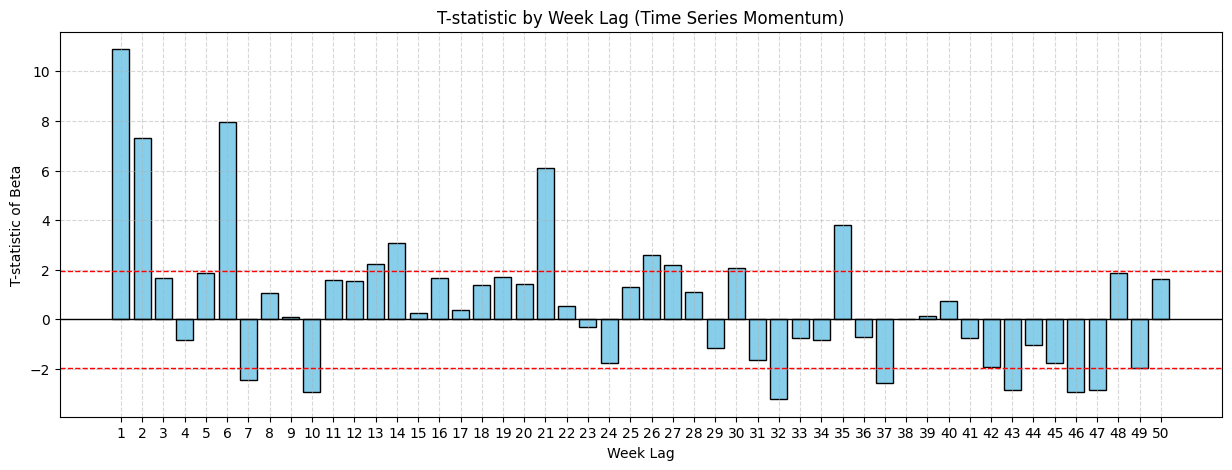

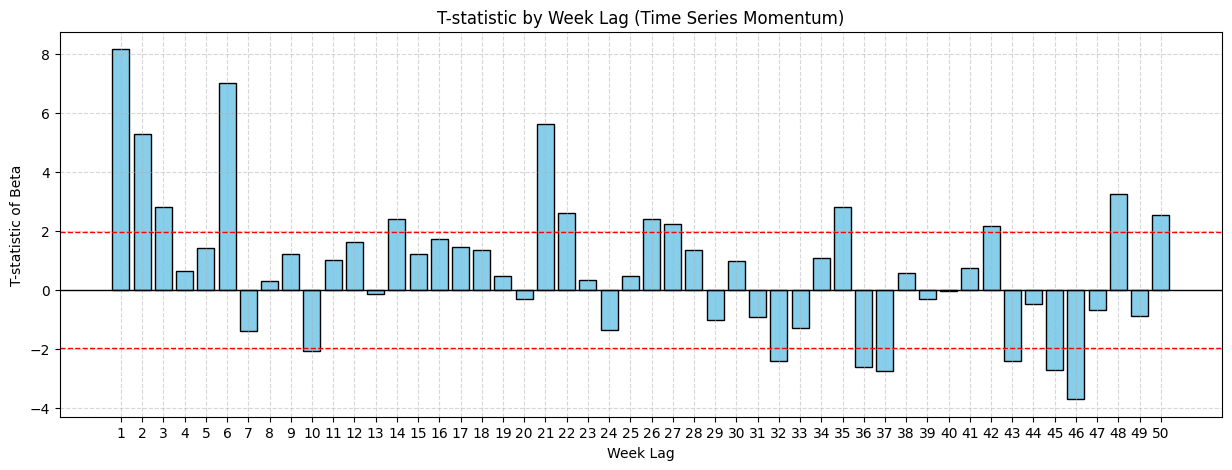

In [ ]:
regression_test = run_tsmom_regressions(returns_weekly, vol, max_lag=50)
sign_regression_test = run_sign_regressions(returns_weekly, vol, max_lag=50)

plot_tstats_by_lag(tstats = regression_test['tstat'])
plot_tstats_by_lag(tstats = sign_regression_test['tstat'])

In [ ]:
sample_vol = exante_volatility(df['ACB'].pct_change())
print(sample_vol.tail(10))

timestamp
2025-03-07    0.131691
2025-03-10    0.131732
2025-03-11    0.130659
2025-03-12    0.130249
2025-03-13    0.130272
2025-03-14    0.129509
2025-03-17    0.129263
2025-03-18    0.128361
2025-03-19    0.127628
2025-03-20    0.126604
Name: ACB, dtype: float64


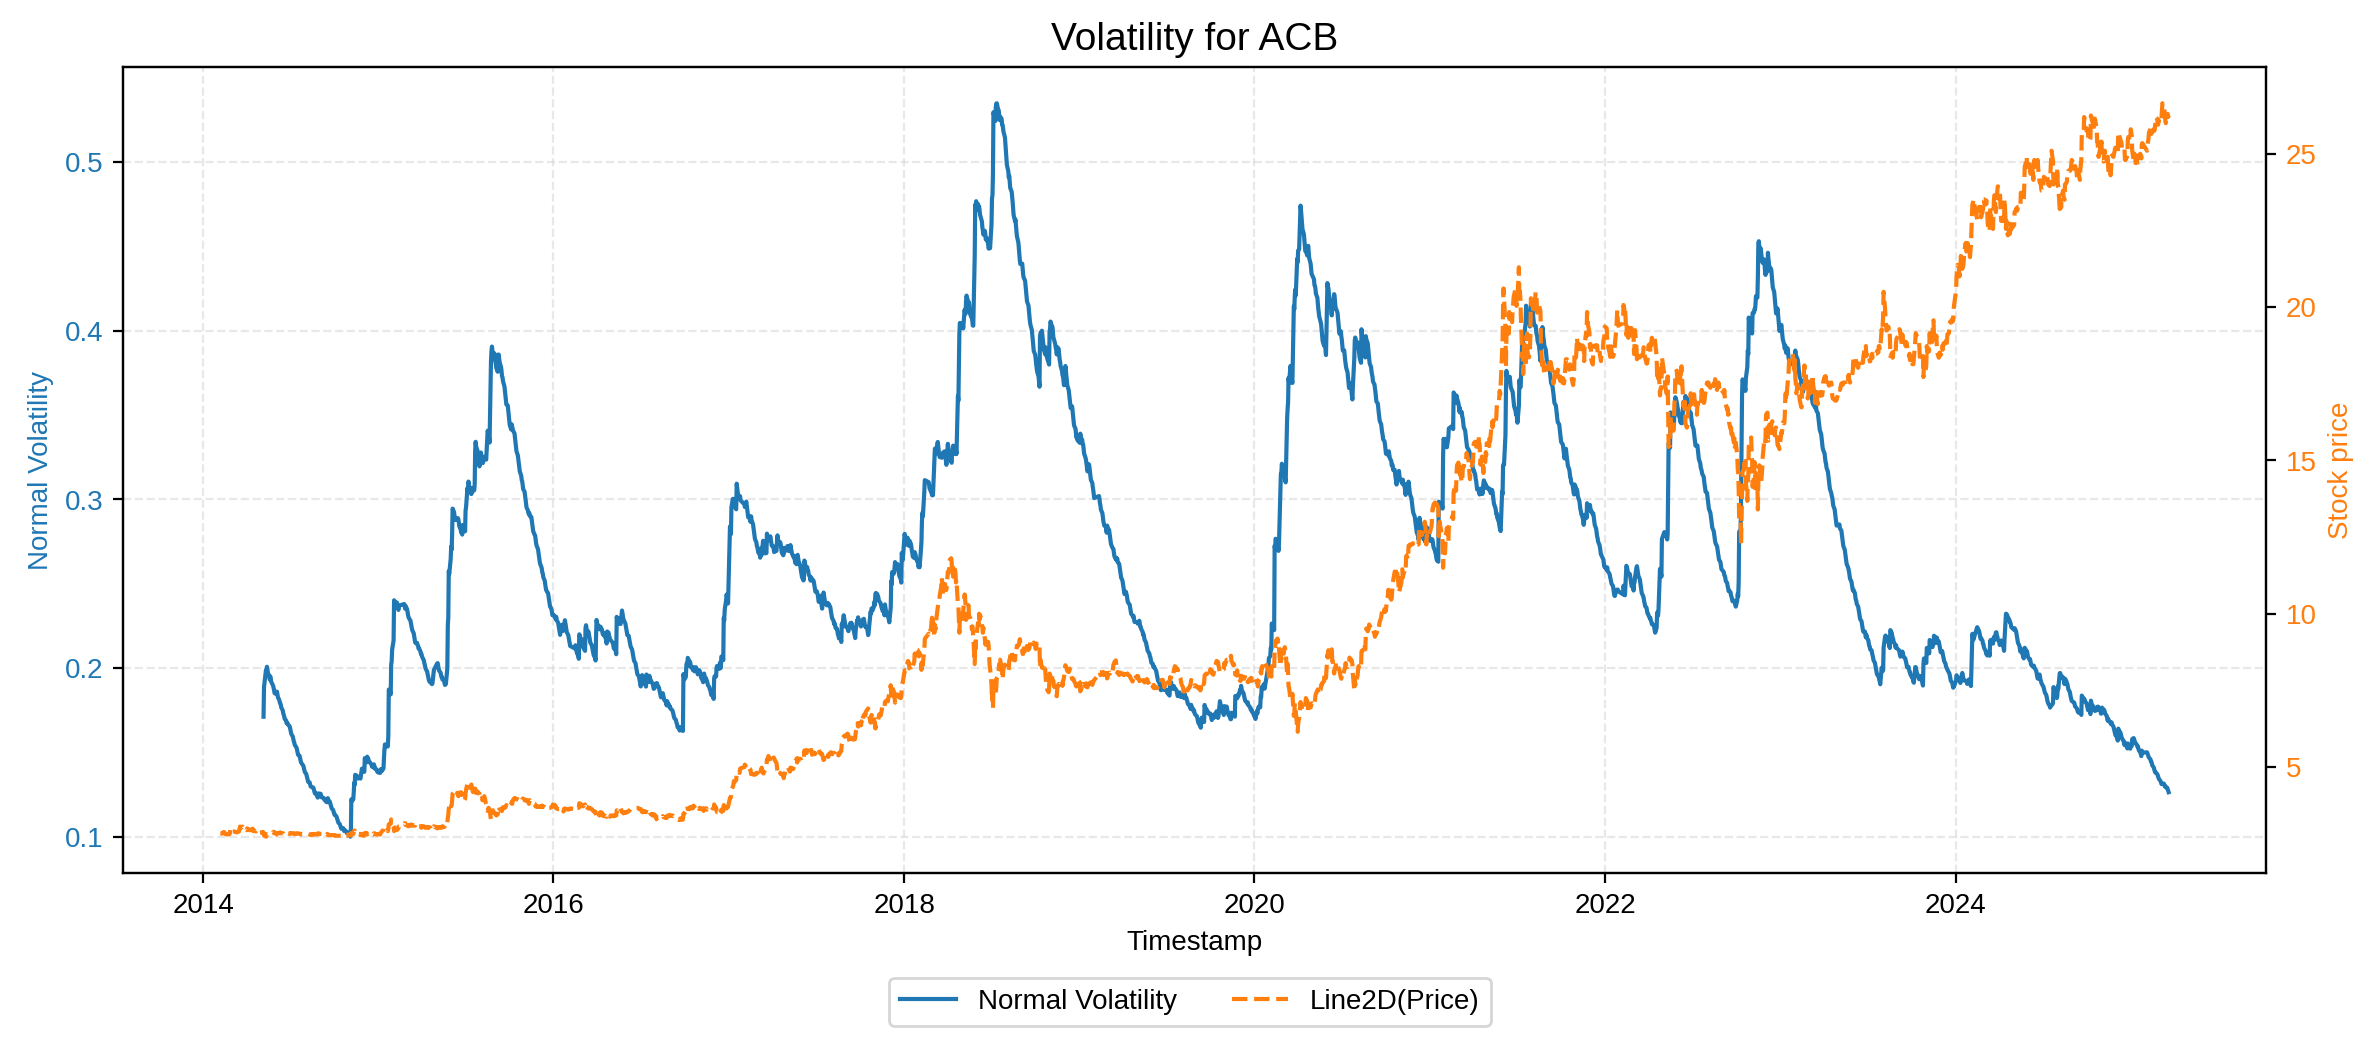

In [ ]:
VOL_TARGET = 0.4
MARGIN_CAP = 2
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# Plot the normal volatility
color = 'tab:blue'
ax.set_xlabel('Timestamp')
ax.set_ylabel('Normal Volatility', color=color)
ax.plot(sample_vol, label='Normal Volatility', color=color)
ax.tick_params(axis='y', labelcolor=color)
ax.grid(True, which='major', linestyle='--', alpha=0.5, color='lightgray') # Adjusted grid

# Create the second y-axis for the target after scaling
ax_ = ax.twinx()

color_ax2 = 'tab:orange'
ax_.set_ylabel('Stock price', color=color_ax2)
ax_.plot(df['ACB'], label='Price', color=color_ax2, linestyle='--')
ax_.tick_params(axis='y', labelcolor=color_ax2)
ax_.grid(False) # Remove grid for the secondary axis to avoid overlap

# Title and Legend
plt.title('Volatility for ACB', fontsize=14)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_.get_legend_handles_labels()
# ax_.legend(lines + lines2, labels + labels2, loc='lower left', fontsize=10)
fig.legend(lines + lines2, labels + lines2, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)

fig.tight_layout()
plt.style.use('seaborn-v0_8-whitegrid')
plt.show()

## Volatility targeting

Volatility target is the soul of the strategy. As the momentum can be risky at some point, we need something to manage the risk but also dynamic with the market.

So the author ideas is just so inverse with the volatiltiy. Just simple is that.
- If the market/stock is not volatile -> use the margin
- If it's volatile but use still want to be in the market -> just buy less, inverse with the volatiltiy.

Ok, let's get it. The author use the volatiltiy target of 40%, mean we will always expose ourself 40% in term of volatility (annually)

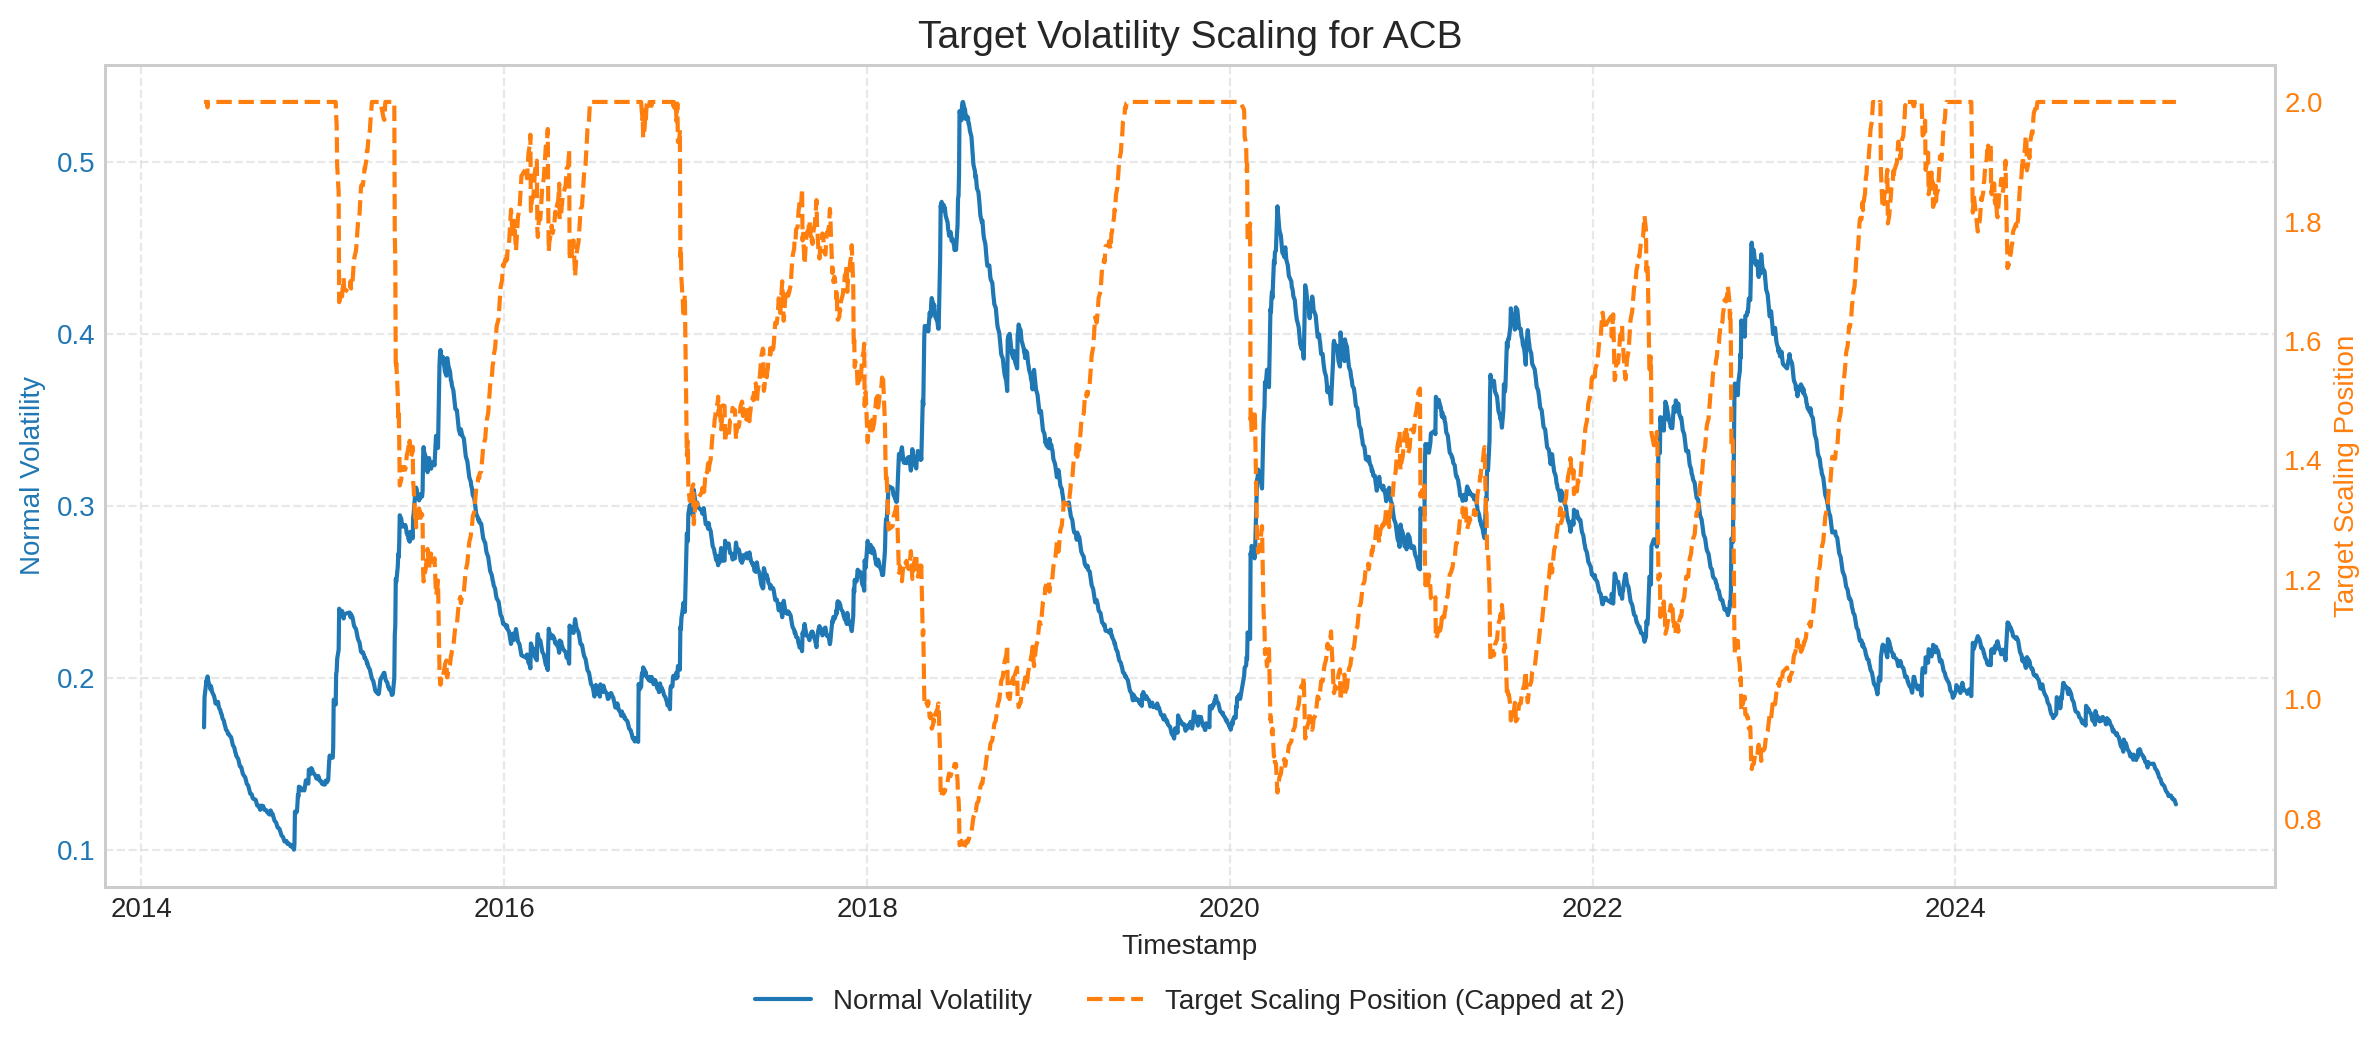

In [ ]:
VOL_TARGET = 0.4
MARGIN_CAP = 2
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# Plot the normal volatility
color = 'tab:blue'
ax.set_xlabel('Timestamp')
ax.set_ylabel('Normal Volatility', color=color)
ax.plot(sample_vol, label='Normal Volatility', color=color)
ax.tick_params(axis='y', labelcolor=color)
ax.grid(True, which='major', linestyle='--', alpha=0.5, color='lightgray') # Adjusted grid

# Create the second y-axis for the target after scaling
ax_ = ax.twinx()
target_scaled = (VOL_TARGET / sample_vol).clip(upper=MARGIN_CAP)
color_ax2 = 'tab:orange'
ax_.set_ylabel('Target Scaling Position', color=color_ax2)
ax_.plot(target_scaled, label='Target Scaling Position (Capped at 2)', color=color_ax2, linestyle='--')
ax_.tick_params(axis='y', labelcolor=color_ax2)
ax_.grid(False) # Remove grid for the secondary axis to avoid overlap

# Title and Legend
plt.title('Target Volatility Scaling for ACB', fontsize=14)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_.get_legend_handles_labels()
# ax_.legend(lines + lines2, labels + labels2, loc='lower left', fontsize=10)
fig.legend(lines + lines2, labels + labels2, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)

fig.tight_layout()
plt.style.use('seaborn-v0_8-whitegrid')
plt.show()

## Momentum signal

$$signal_t = sign(r_{t-12,t}^s)$$

In [ ]:
def compute_signal(returns, window=6):
    """
    Compute the trading signal based on cumulative standardized returns over a rolling window.

    The paper uses:
       signal_t = sign(r_{t-12,t}^s)
    where r_{t-12,t}^s is the return from t-window to t.

    """

    cum_rets = returns.rolling(window=window).apply(lambda x: np.prod(x))

    # Signal is the sign of the cumulative standardized return.
    signal = np.sign(cum_rets).clip(lower=0)
    return signal


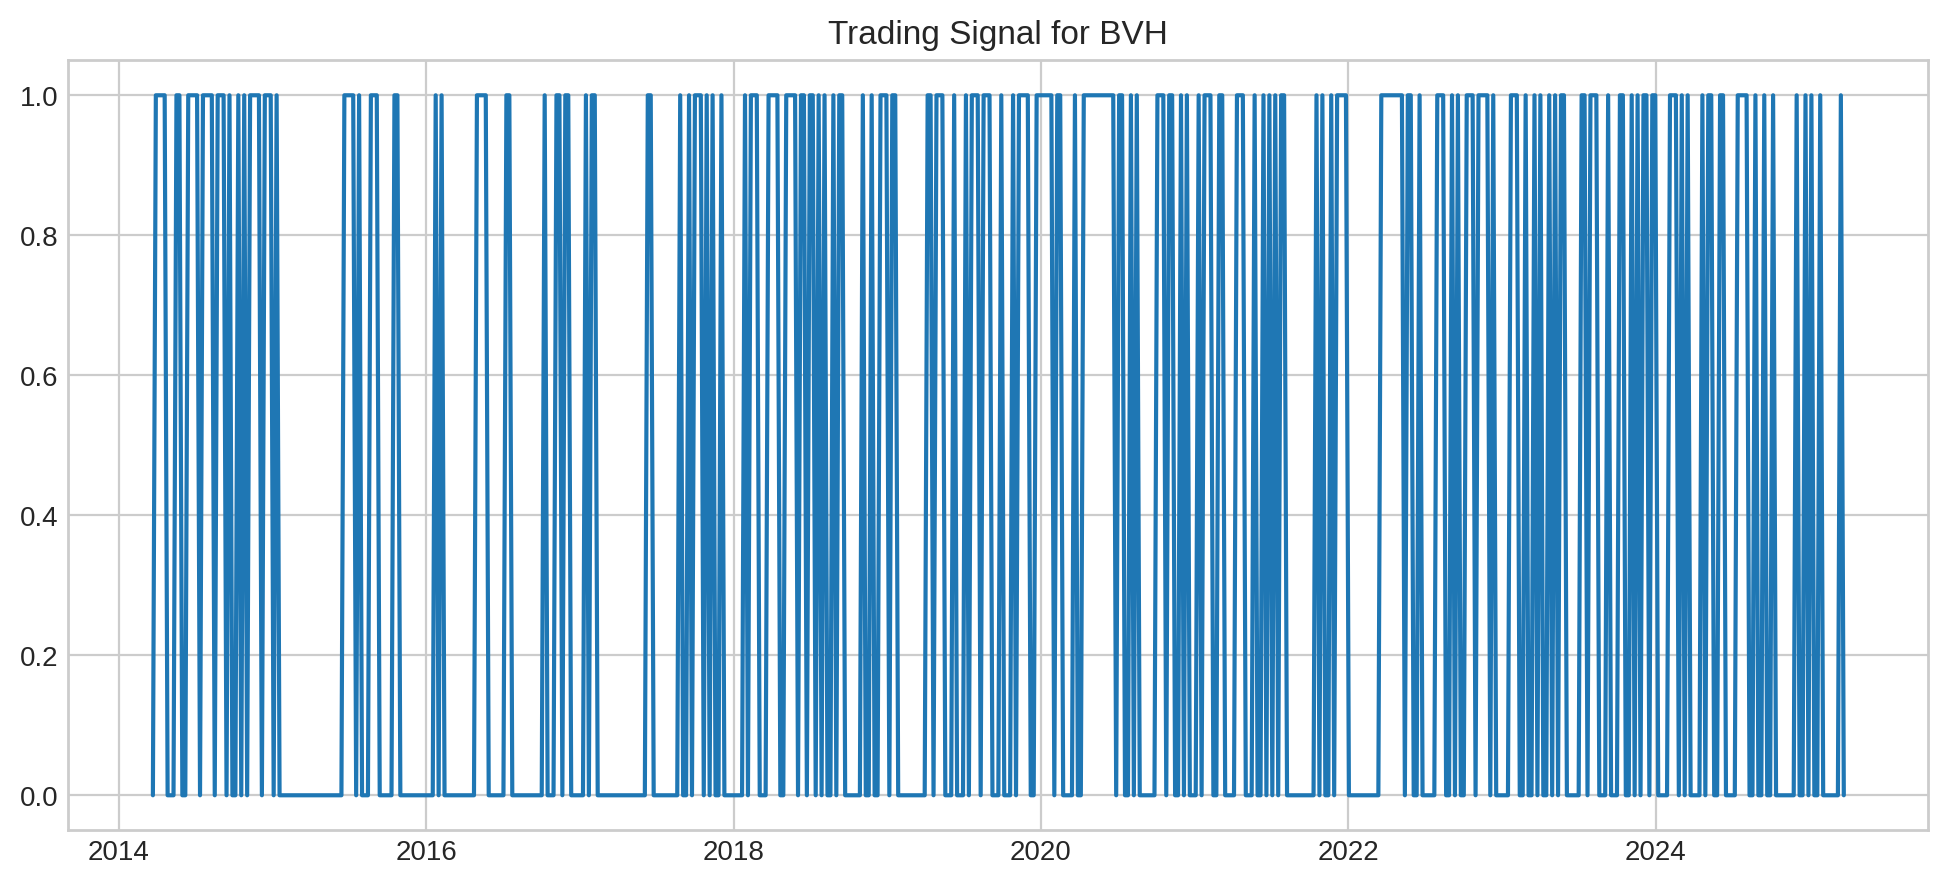

In [ ]:
stock = 'BVH'
signal = compute_signal(returns_weekly[stock], window=6)
plt.figure(figsize=(12,5), dpi=200)
plt.title(f'Trading Signal for {stock}')
plt.plot(signal)

## Backtest
Lợi nhuận của từng cổ:
$$
r_{t,t+1} = sign(r_{t-6, t})\frac{0.4}{\sigma_t}r_{t,t+1}
$$

Lợi nhuận của TSMOM
$$
r_{t,t+1}^{TSMOM} = \frac{1}{S_t} \sum sign(r_{t-6, t})\frac{0.4}{\sigma_t}r_{t,t+1}
$$

In [ ]:
def exante_volatility(returns, com=60, annualization=252):
    """
    Compute the ex ante annualized volatility using an exponentially weighted variance
    with the center of mass (com) parameter.

    The formula is:
      σ_t^2 = 261 * Σ_{i=0}^∞ w_i (r_{t-1-i} - r̄_t)^2,
    where the weights are given by the exponential decay with:
      alpha = 1 / (com + 1).

    Parameters:
        returns (pd.Series): Asset returns.
        com (int): Center of mass for the exponential weights (default is 60).

    Returns:
        pd.Series: The ex ante volatility σ_t (annualized by multiplying the variance by 261).
                   Volatility is computed using returns up to t-1.
    """
    # Shift returns by 1 so volatility at time t uses only past returns.
    ewm_variance = returns.ewm(com=com, adjust=False,min_periods=com).var()
    sigma = np.sqrt(annualization * ewm_variance)
    return sigma

def compute_signal(returns, window=6):
    """
    Compute the trading signal based on cumulative standardized returns over a rolling window.

    The paper uses:
       signal_t = sign(r_{t-12,t}^s)
    where r_{t-12,t}^s is the return from t-window to t.

    """
    cum_rets = returns.rolling(window=window).apply(lambda x: np.prod(1+x)-1)
    signal = np.sign(cum_rets).clip(lower=0)
    return signal


def backtest(daily_price, vol_target=0.4, look_back = 6, commission=0.001):
    """
    Backtest a trading strategy that goes long (short) when the signal is +1 (-1).

    Parameters:
        returns (pd.Series): Asset returns.

    Returns:
        pd.Series: The strategy returns.
    """
    ## compute the daily ex ante volatility first
    daily_return = daily_price.pct_change().dropna()
    weekly_return = daily_price.resample('W').last().pct_change().dropna()

    daily_vol = exante_volatility(daily_return, com=60)
    weekly_vol = daily_vol.resample('W').last().ffill()

    ## position sizing
    position_size = vol_target / weekly_vol
    position_size = position_size.clip(upper=2) ## max margin is 2

    signal = compute_signal(weekly_return, window=look_back)
    position = signal * position_size

    trade_cost = 2 * commission * position.diff().abs().shift(-1)

    ## Compute strategy returns:
    # Use the previous period's position (position.shift(1)) applied to the current week's return,
    # and subtract any commission cost incurred at the beginning of the period.
    strat_ret = (position * weekly_return.shift(-1)
                 - trade_cost)

    return_df = pd.DataFrame({
        'raw_rets': weekly_return,
        'signal': signal,
        'position_size': position_size,
        'position': position,
        'trade_cost': trade_cost,
        'strat_rets': strat_ret
    })

    return return_df.dropna()


def calculate_metrics(returns):
    """
    Calculate the annualized return, volatility, and Sharpe ratio.

    Parameters:
        returns (pd.Series): The strategy returns.

    Returns:
        tuple: Annualized return, volatility, and Sharpe ratio, ....
    """
    ann_return = returns.mean() * 52
    ann_vol = returns.std() * np.sqrt(52)
    sharpe = ann_return / ann_vol
    skew = returns.skew()
    kurt = returns.kurtosis()
    summary = pd.DataFrame({
        'Annualized Return': ann_return.round(4),
        'Annualized Volatility': ann_vol.round(4),
        'Sharpe Ratio': sharpe.round(2),
        'Skewness': skew.round(2),
        'Kurtosis': kurt.round(2),
    }, index = ['metrics'])
    return summary.T


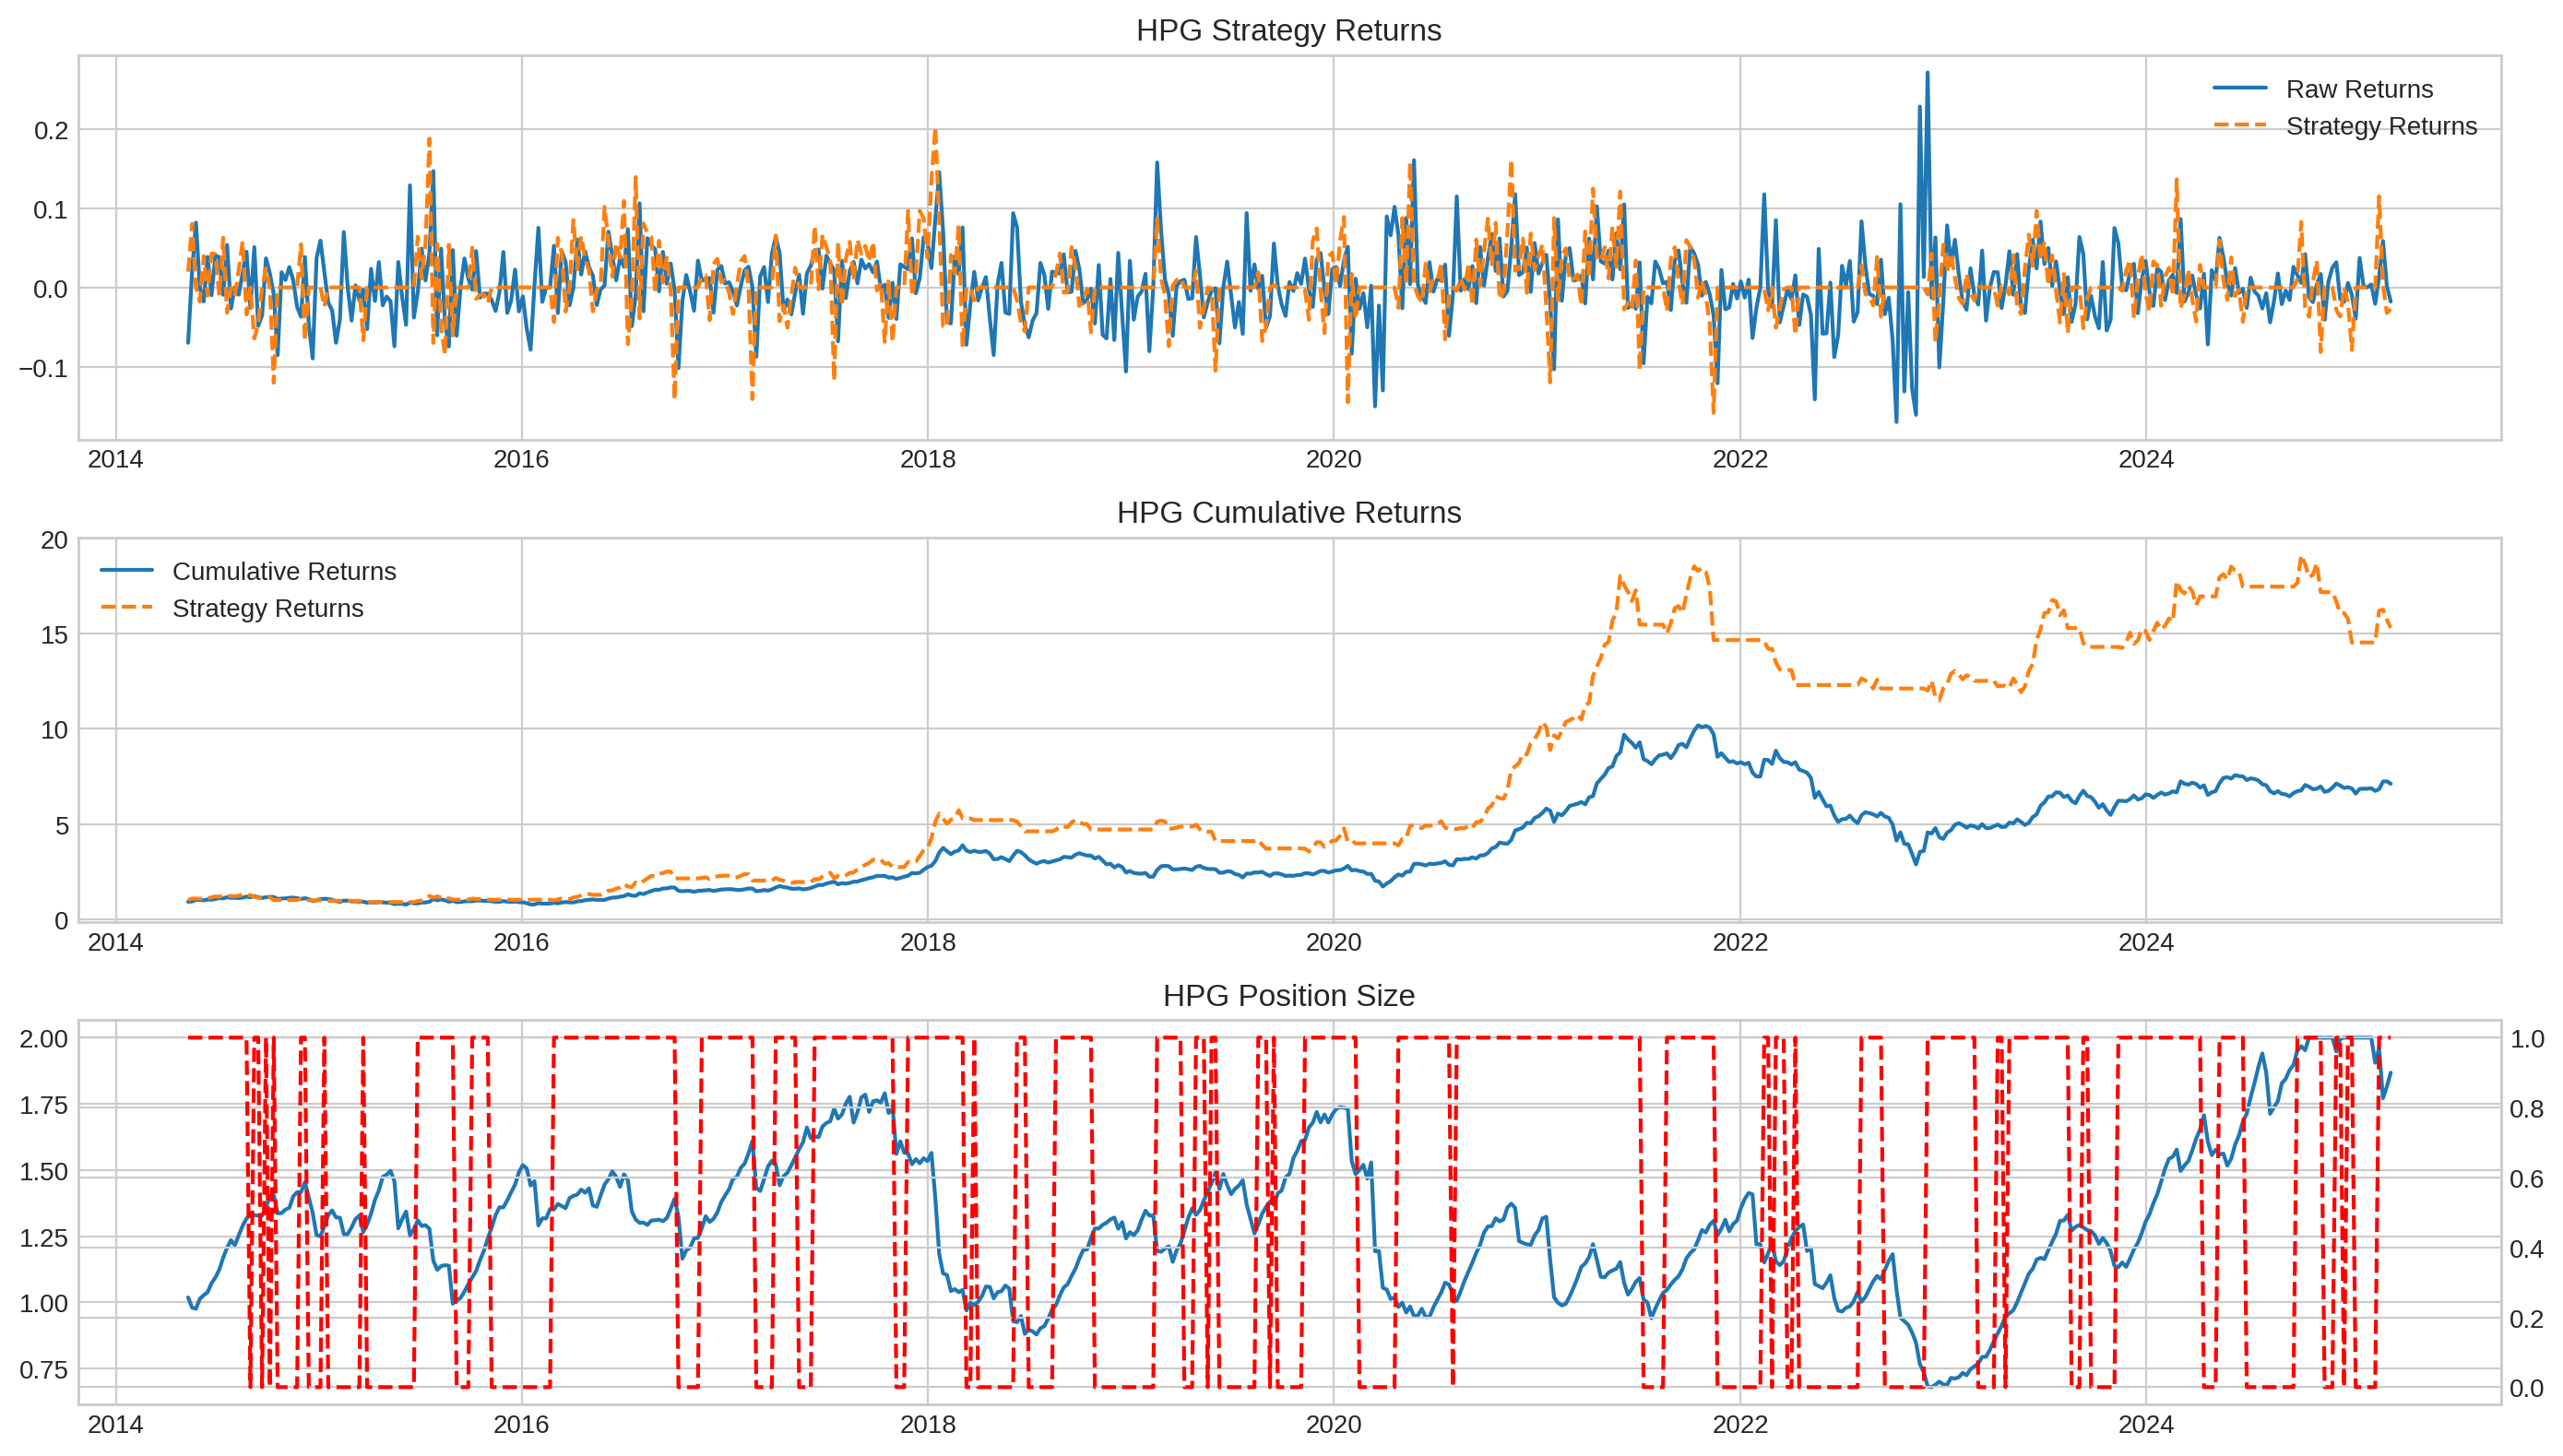

Buy and Hold
                       metrics
Annualized Return       0.2363
Annualized Volatility   0.3365
Sharpe Ratio            0.7000
Skewness                0.3600
Kurtosis                3.6700
-----
TSMOM
                       metrics
Annualized Return       0.2923
Annualized Volatility   0.2903
Sharpe Ratio            1.0100
Skewness                0.4400
Kurtosis                4.1600


In [ ]:
symbol = 'HPG'
stock_price = df[symbol]
strategy = backtest(stock_price.dropna(), vol_target=0.4, look_back=6,commission=0)


fig, ax = plt.subplots(3,1,figsize=(14, 8), dpi=200)

ax[0].plot(strategy['raw_rets'], label='Raw Returns')
ax[0].plot(strategy['strat_rets'], label='Strategy Returns', linestyle='--')
ax[0].set_title(f'{symbol} Strategy Returns')
ax[0].legend()

ax[1].plot((1+strategy['raw_rets']).cumprod(), label='Cumulative Returns')
ax[1].plot((1+strategy['strat_rets']).cumprod(), label='Strategy Returns', linestyle='--')
ax[1].set_title(f'{symbol} Cumulative Returns')
ax[1].legend()

ax[2].plot(strategy['position_size'])
ax[2].set_title(f'{symbol} Position Size')
ax_2 = ax[2].twinx()
ax_2.plot(strategy['signal'], color='red', linestyle='--')
plt.tight_layout()
plt.show()


print('Buy and Hold')
print(calculate_metrics(strategy['raw_rets']))
print('-----')
print('TSMOM')
print(calculate_metrics(strategy['strat_rets']))

In [ ]:
## loop for 60 stocks
returns = pd.DataFrame(columns=df.columns)
metrics = pd.DataFrame(columns=df.columns)
for symbol in df.columns:
    print(f'Running backtest for {symbol}')
    returns[symbol] = backtest(df[symbol], vol_target=0.4, look_back=6,commission=0.001)['strat_rets']
    sample = calculate_metrics(returns[symbol]).rename(columns={'metrics':symbol})
    metrics[symbol] = sample[symbol]
returns


Running backtest for ACB
Running backtest for ASM
Running backtest for BVH
Running backtest for CII
Running backtest for CTD
Running backtest for CTG
Running backtest for DBC
Running backtest for DIG
Running backtest for DLG
Running backtest for DPM
Running backtest for DRC
Running backtest for DXG
Running backtest for EIB
Running backtest for FCN
Running backtest for FIT
Running backtest for FPT
Running backtest for GAS
Running backtest for GMD
Running backtest for HAG
Running backtest for HCM
Running backtest for HDC
Running backtest for HDG
Running backtest for HHS
Running backtest for HPG
Running backtest for HQC
Running backtest for HSG
Running backtest for IDI
Running backtest for IJC
Running backtest for KBC
Running backtest for KDC
Running backtest for KDH
Running backtest for KSB
Running backtest for LCG
Running backtest for MBB
Running backtest for MSN
Running backtest for NKG
Running backtest for NLG
Running backtest for OGC
Running backtest for PAN
Running backtest for PDR


symbol,ACB,ASM,BVH,CII,CTD,CTG,DBC,DIG,DLG,DPM,...,TCM,TSC,TTF,VCB,VCG,VHC,VIC,VIX,VND,VNM
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-05-11,0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,...,-0.0,-0.021764,-0.000000,0.000000,-0.000000,-0.008403,0.000000,0.011030,0.000000,-0.000000
2014-05-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-0.000026,0.000000,-0.000000,0.000000,-0.026075,0.000000,0.000000,0.000000,0.000000
2014-05-25,0.000000,-0.000000,-0.001625,-0.000000,0.000000,-0.003151,0.000000,0.000000,0.000000,-0.002580,...,0.0,0.026366,-0.000000,-0.002354,0.000000,0.018533,-0.003277,-0.000964,0.000000,-0.000000
2014-06-01,-0.000000,0.000000,-0.030068,-0.000000,-0.000000,-0.033721,-0.000000,0.000000,0.000000,-0.022849,...,0.0,0.168920,0.000000,-0.010562,0.000000,-0.070207,-0.086778,0.079197,0.000000,0.000000
2014-06-08,-0.000000,0.000000,0.027408,0.000000,0.000000,0.000000,0.000000,-0.001444,-0.000000,-0.002779,...,0.0,0.254189,0.000000,-0.002443,0.000000,0.000000,-0.000000,0.002697,-0.000000,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-16,0.034951,-0.004000,0.105852,0.021832,0.040817,0.042224,-0.002830,-0.002722,-0.002245,0.052871,...,-0.0,0.026505,0.010234,-0.004000,-0.003766,-0.003349,-0.004000,0.155250,0.059090,-0.004000
2025-02-23,-0.015267,0.048579,-0.034544,-0.033527,-0.039940,-0.000108,0.083509,0.038634,0.011205,-0.025190,...,-0.0,0.033158,0.005130,0.004497,-0.007583,0.021127,0.027060,0.017115,0.023953,0.026059
2025-03-02,0.050000,-0.061338,0.002471,-0.000079,0.027693,0.041251,0.050809,0.020863,0.005693,0.007755,...,-0.0,-0.053506,-0.027309,0.038455,0.018976,-0.026457,0.199027,0.046541,0.009713,0.016077


In [ ]:
# metrics.T.to_excel('metrics.xlsx')

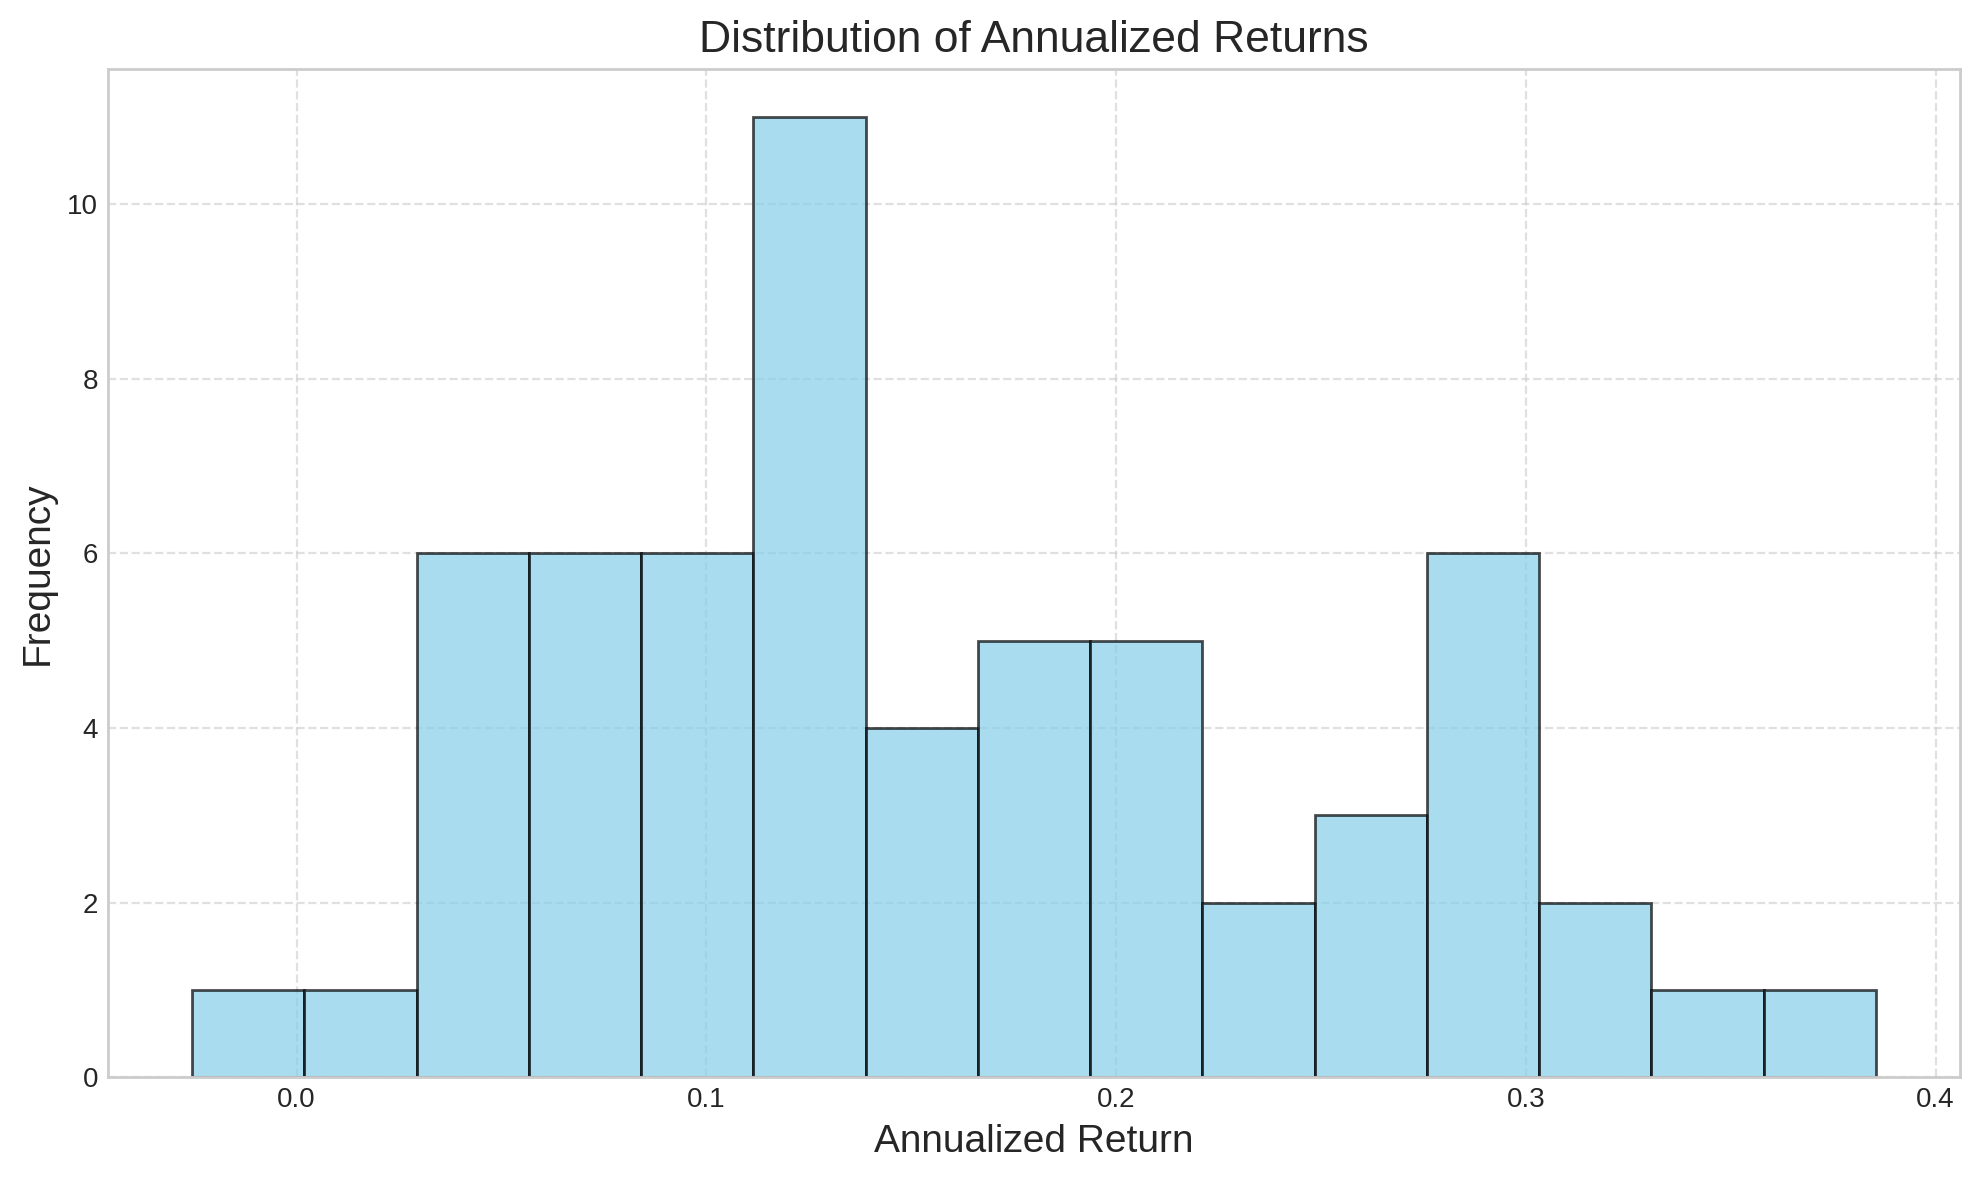

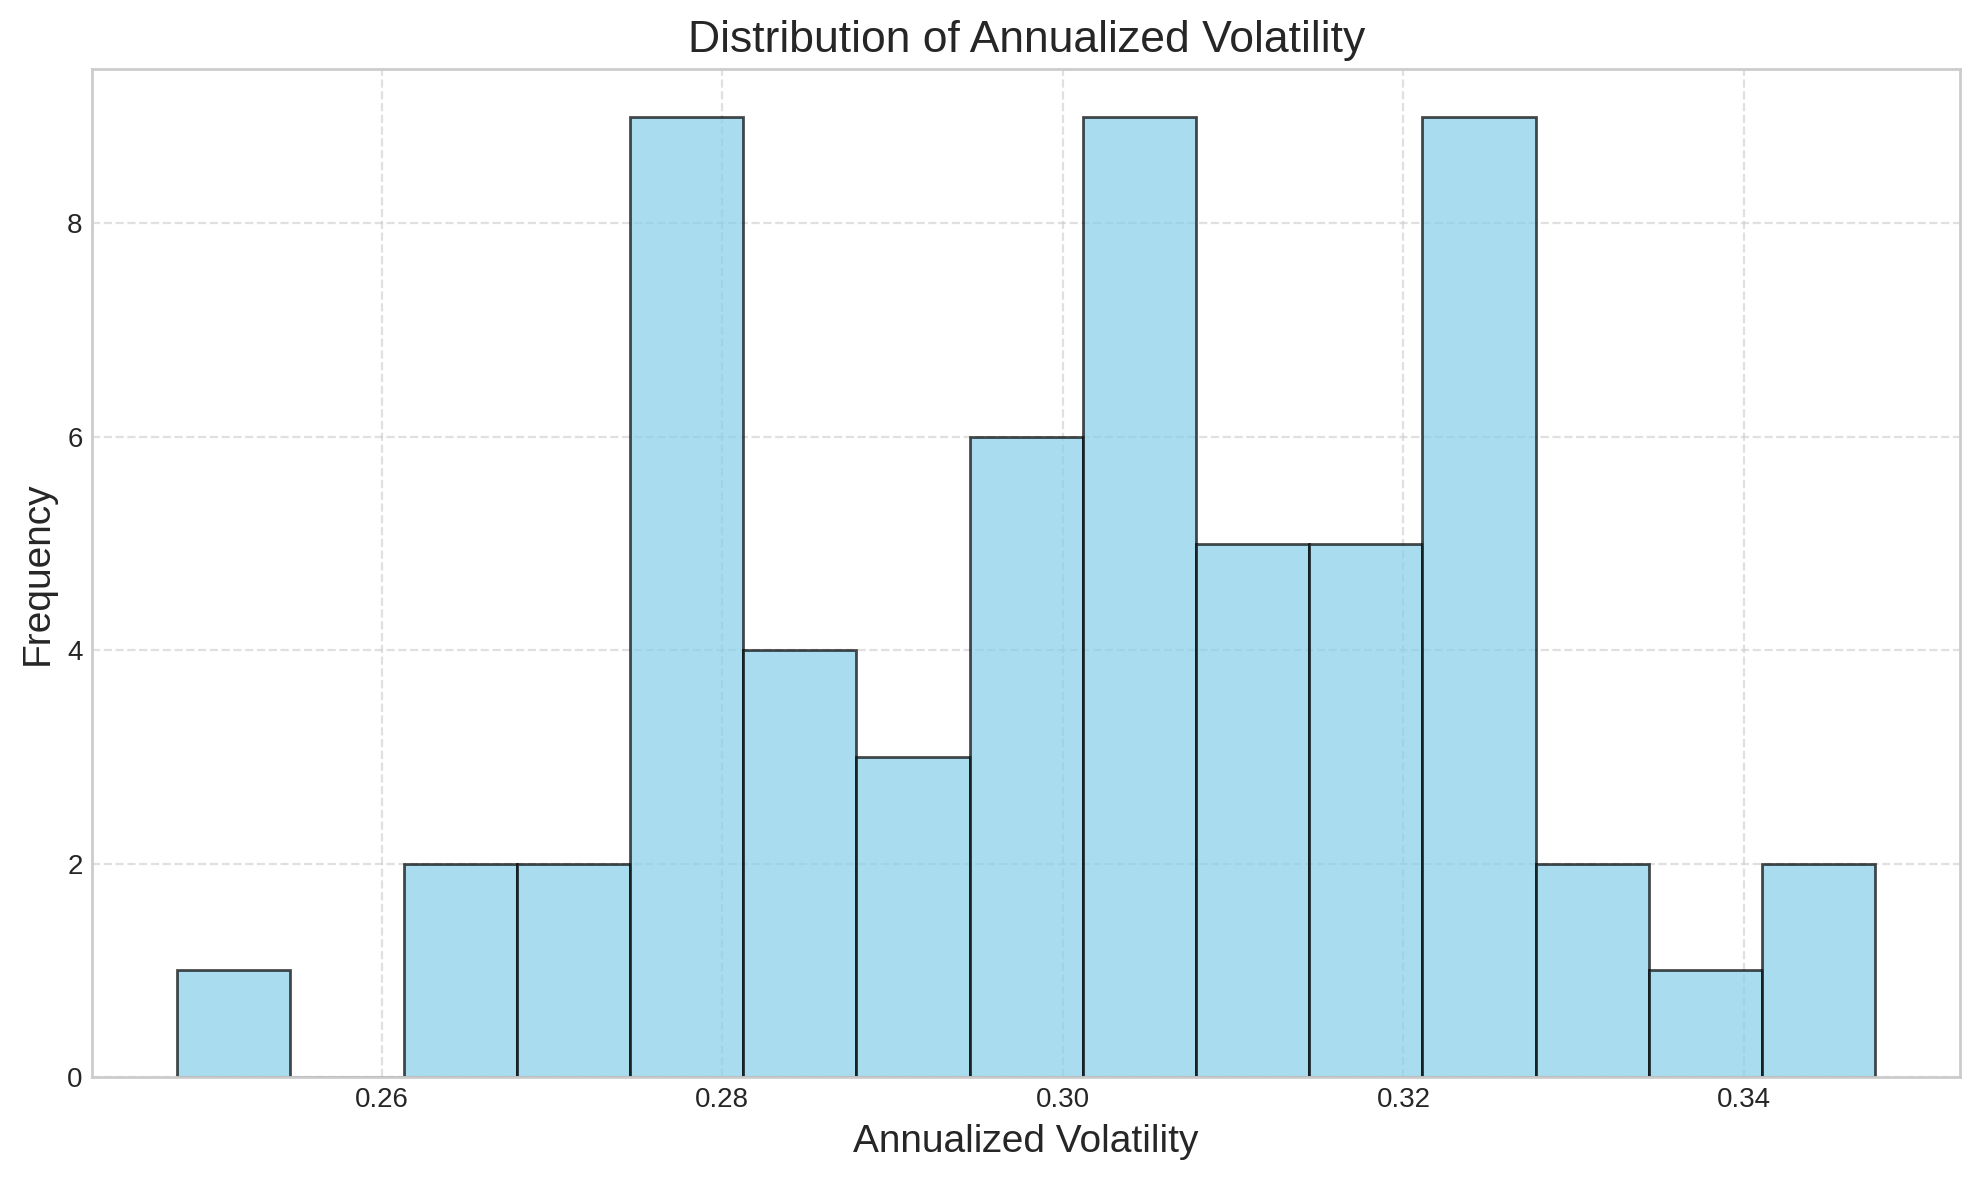

In [ ]:
import matplotlib.pyplot as plt

# Assuming metrics is a DataFrame and 'Annualized Return' is one of its indices
data = metrics.loc['Annualized Return', :].to_list()

plt.figure(figsize=(10, 6), dpi=200)
plt.hist(data, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Annualized Returns', fontsize=16)
plt.xlabel('Annualized Return', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Assuming metrics is a DataFrame and 'Annualized Return' is one of its indices
data = metrics.loc['Annualized Volatility', :].to_list()

plt.figure(figsize=(10, 6), dpi=200)
plt.hist(data, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Annualized Volatility', fontsize=16)
plt.xlabel('Annualized Volatility', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## TSMOM 60 stocks

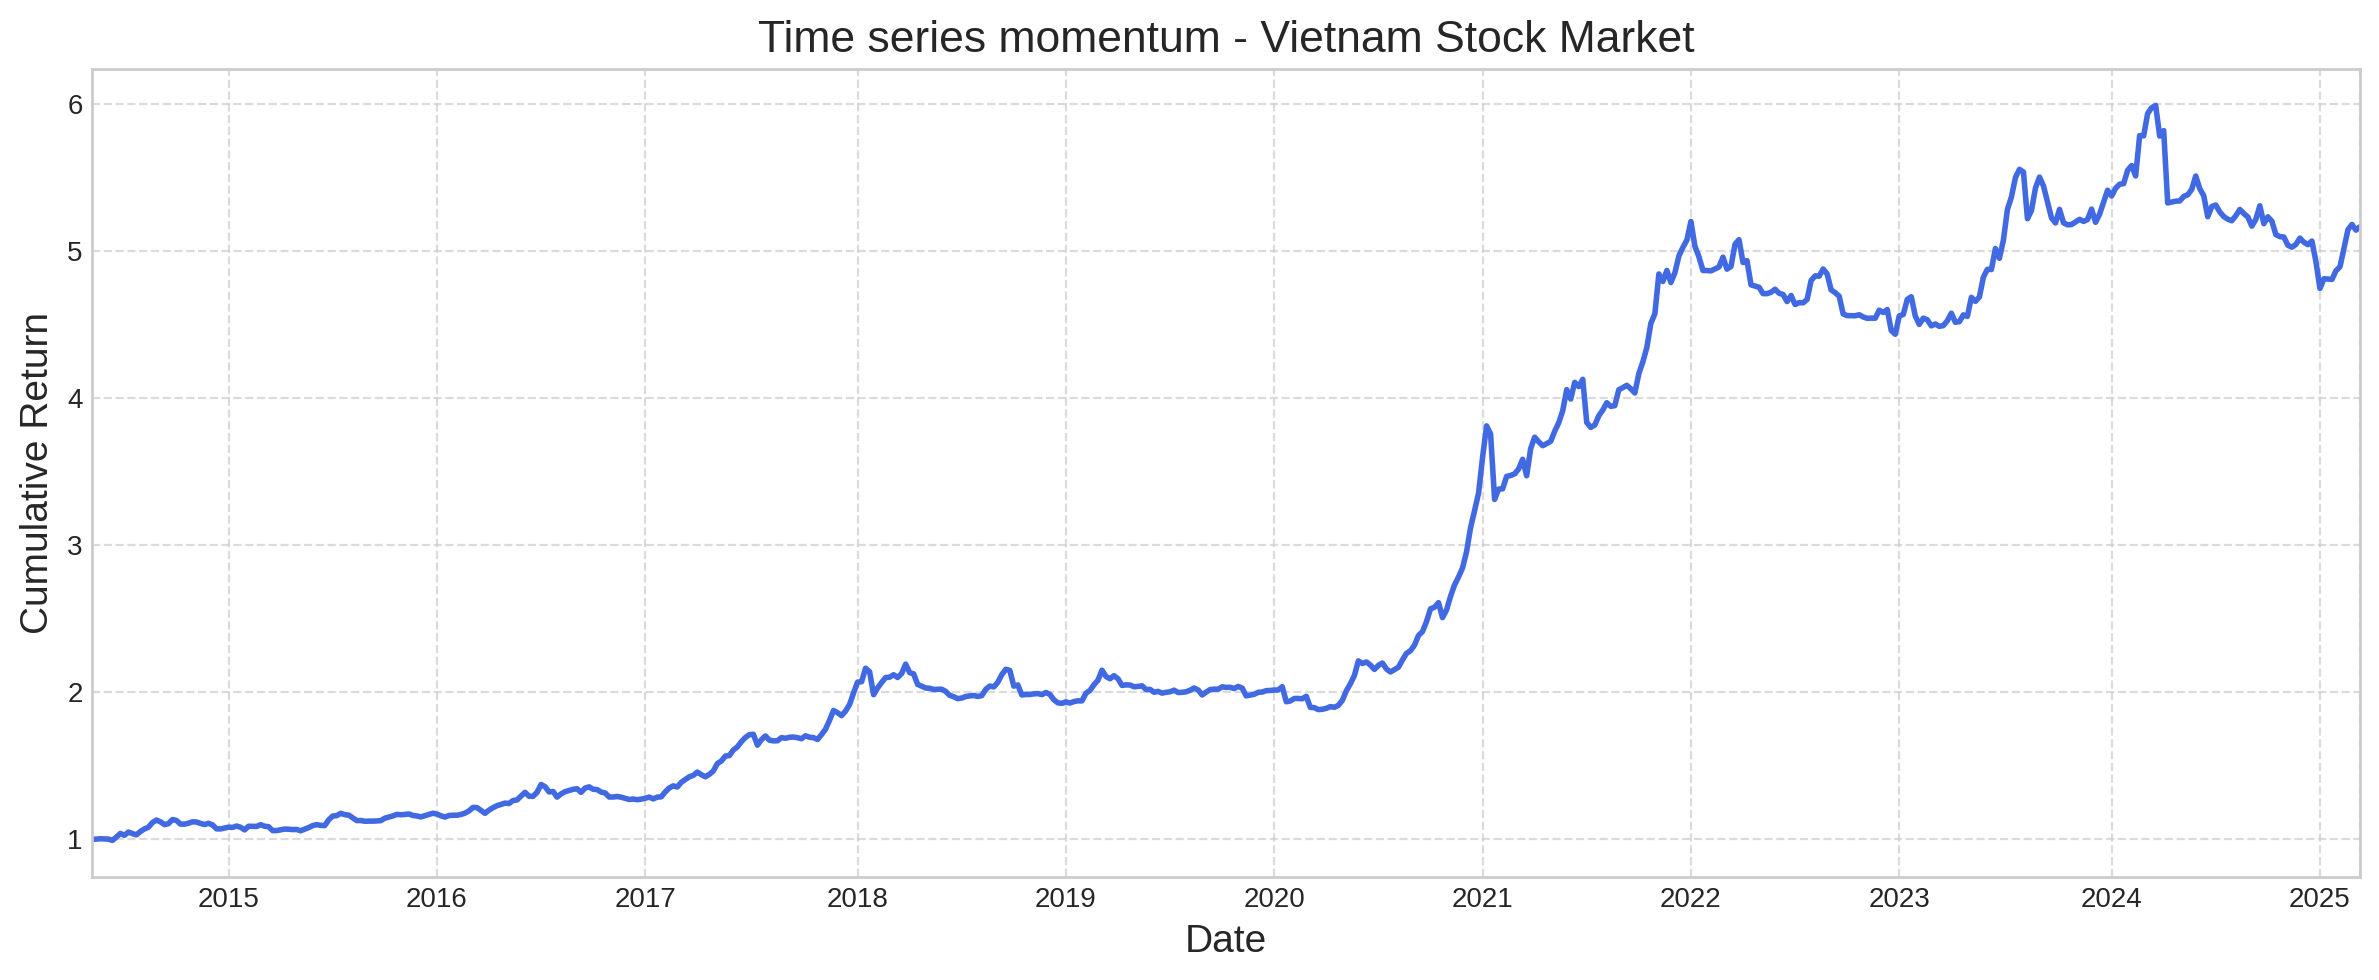

In [ ]:
import matplotlib.pyplot as plt

# Create the cumulative product series from the average returns
cum_returns = (1 + returns.mean(axis=1)).cumprod()

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# Plot the cumulative returns with custom styling
cum_returns.plot(ax=ax, color='royalblue', lw=2)

# Set chart title and axis labels
ax.set_title("Time series momentum - Vietnam Stock Market", fontsize=16)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Cumulative Return", fontsize=14)

# Add grid lines for better readability
ax.grid(True, linestyle='--', alpha=0.7)

# Tight layout for better spacing
plt.tight_layout()
plt.show()


In [ ]:
url = "https://drive.google.com/file/d/1CBCg5qAoKuJa_6EH5rVbo0ItEPVsBK7I/view?usp=share_link"
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
vni = pd.read_csv(url, index_col=0).rename(columns={'time':'timestamp'})
vni.set_index('timestamp', inplace=True)
vni.index = pd.to_datetime(vni.index)
vni = vni.resample('W').last().ffill()
vni['vni'] = vni.close.pct_change().dropna()


In [ ]:
tsmom = returns.mean(axis=1).to_frame('tsmom')
tsmom['vni'] = vni['vni']
tsmom = tsmom.resample('M').apply(lambda x: (1+x).prod()-1)
tsmom

,tsmom,vni
timestamp,,
2014-05-31,0.001908,-0.063166
2014-06-30,0.036182,0.068939
2014-07-31,-0.009279,0.036834
2014-08-31,0.098139,0.060836
2014-09-30,0.002996,-0.049745
...,...,...
2024-11-30,-0.010512,-0.019653
2024-12-31,-0.023109,0.038303
2025-01-31,-0.024550,-0.007913


                            OLS Regression Results                            
Dep. Variable:                  tsmom   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     37.56
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           1.46e-13
Time:                        09:35:36   Log-Likelihood:                 253.30
No. Observations:                 131   AIC:                            -500.6
Df Residuals:                     128   BIC:                            -492.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0053      0.004      1.473      0.1

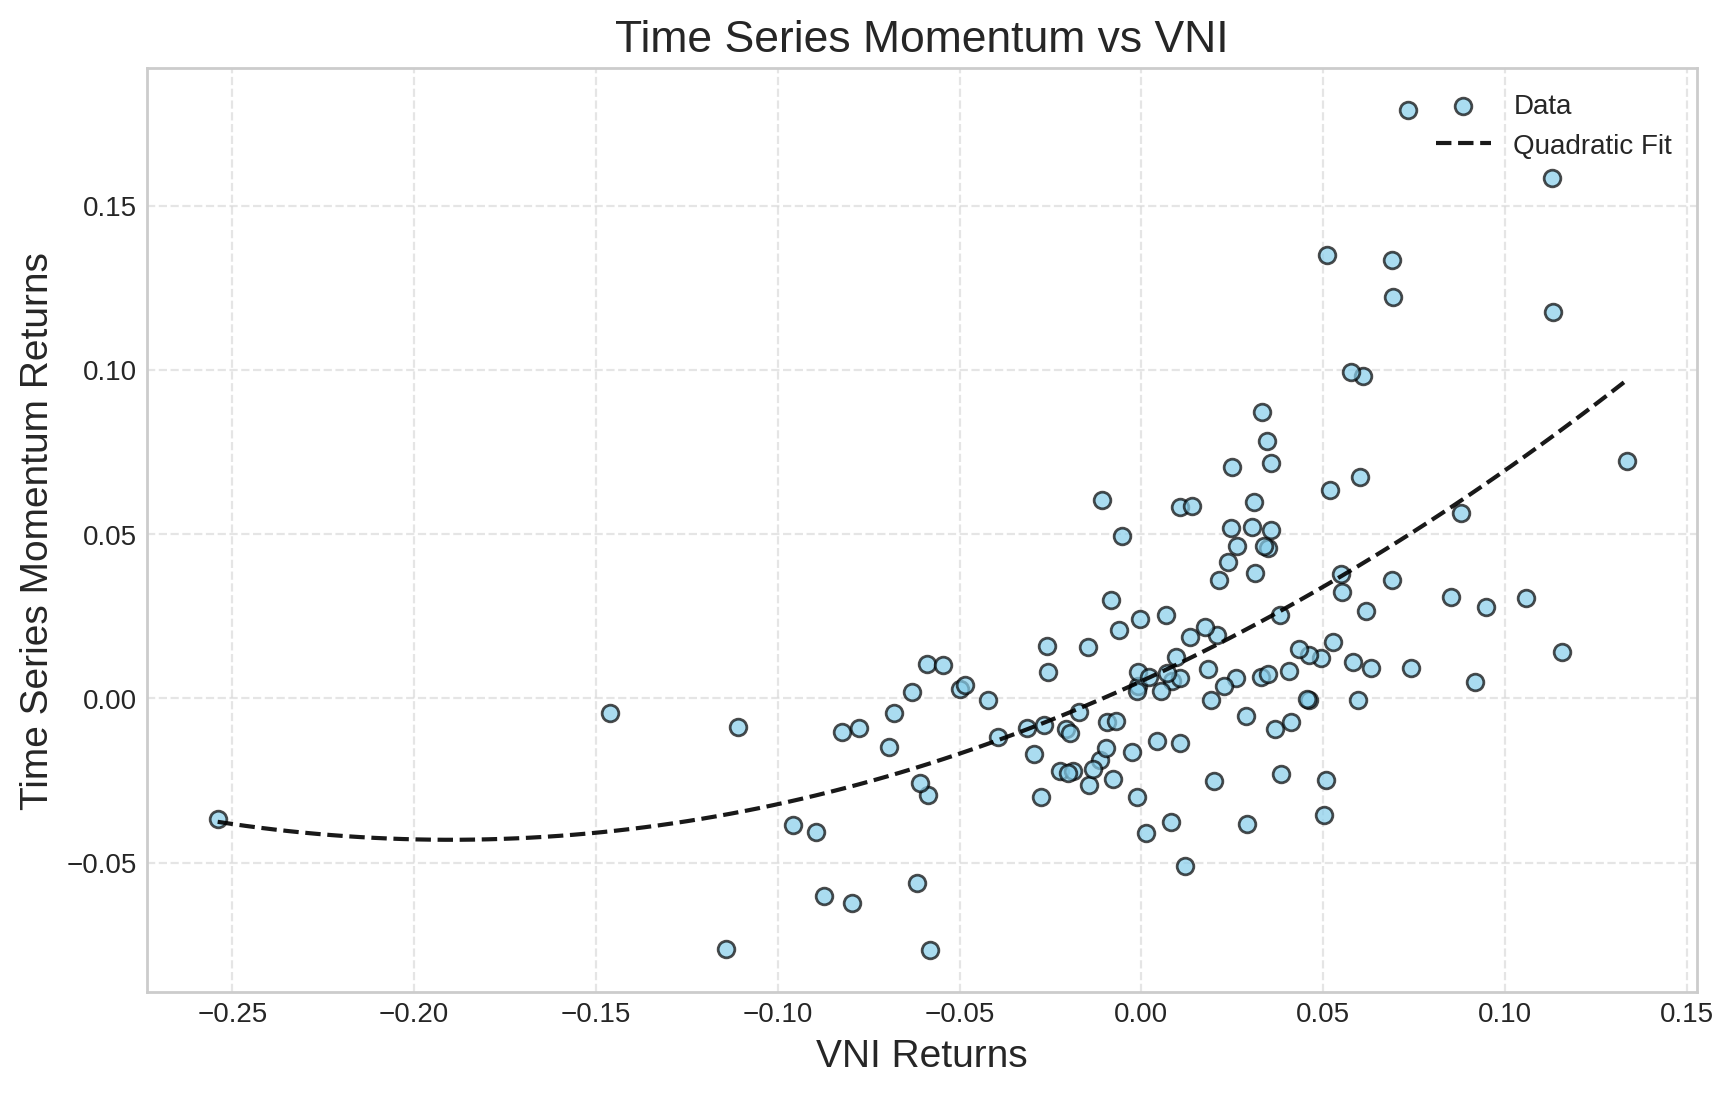

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Prepare your data
x = tsmom['vni']
y = tsmom['tsmom']

# 2. Create the design matrix for a quadratic model: y = β0 + β1*x + β2*x^2
X = pd.DataFrame({
    'x': x,
    'x_sq': x**2
})
X = sm.add_constant(X)  # adds an intercept term

# 3. Fit the OLS model
model = sm.OLS(y, X).fit()
print(model.summary())  # optional: view regression summary

# 4. Generate a smooth range of x-values and predict y
x_fit = np.linspace(x.min(), x.max(), 100)
X_fit = pd.DataFrame({
    'x': x_fit,
    'x_sq': x_fit**2
})
X_fit = sm.add_constant(X_fit)
y_fit = model.predict(X_fit)

# 5. Plot the scatter and the fitted quadratic
plt.figure(figsize=(10, 6), dpi=200)
plt.scatter(x, y, color='skyblue', edgecolor='black', alpha=0.7, label='Data')
plt.plot(x_fit, y_fit, color='black', linestyle='--',alpha=0.9, linewidth=1.5, label='Quadratic Fit')
plt.title('Time Series Momentum vs VNI', fontsize=16)
plt.xlabel('VNI Returns', fontsize=14)
plt.ylabel('Time Series Momentum Returns', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
